#### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import re

sns.set(style='whitegrid')

#### 2. Load the Data

In [2]:
df = pd.read_csv("../data/processed_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (425, 16)


,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee type,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday,1,Summer
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday,1,Summer


#### 3. Basic Info

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Date                      425 non-null    str  
 1   Country                   425 non-null    str  
 2   Local                     425 non-null    str  
 3   Industry Sector           425 non-null    str  
 4   Accident Level            425 non-null    str  
 5   Potential Accident Level  425 non-null    str  
 6   Gender                    425 non-null    str  
 7   Employee type             425 non-null    str  
 8   Critical Risk             425 non-null    str  
 9   Description               425 non-null    str  
 10  Year                      425 non-null    int64
 11  Month                     425 non-null    int64
 12  Day                       425 non-null    int64
 13  Weekday                   425 non-null    str  
 14  WeekofYear                425 non-null    int64
 15  

,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee type,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season
count,425,425,425,425,425,425,425,425,425,425,425.000000,425.000000,425.000000,425,425.000000,425
unique,287,3,12,3,5,6,2,3,33,411,NaN,NaN,NaN,7,NaN,4
top,2017-02-08,Country_01,Local_03,Mining,I,IV,Male,Third Party,Others,During the activity of chuteo of ore in hopper...,NaN,NaN,NaN,Thursday,NaN,Autumn
freq,6,251,90,241,316,143,403,189,232,3,NaN,NaN,NaN,79,NaN,146
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.329412,5.254118,14.981176,NaN,20.955294,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.470554,3.189959,8.661051,NaN,14.009612,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,1.000000,1.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,3.000000,8.000000,NaN,9.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,5.000000,15.000000,NaN,18.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,7.000000,22.000000,NaN,30.000000,NaN


#### 4. Missing Values Analysis

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Date                        0
Country                     0
Local                       0
Industry Sector             0
Accident Level              0
Potential Accident Level    0
Gender                      0
Employee type               0
Critical Risk               0
Description                 0
Year                        0
Month                       0
Day                         0
Weekday                     0
WeekofYear                  0
Season                      0
dtype: int64


#### 5. Target Variable Distribution

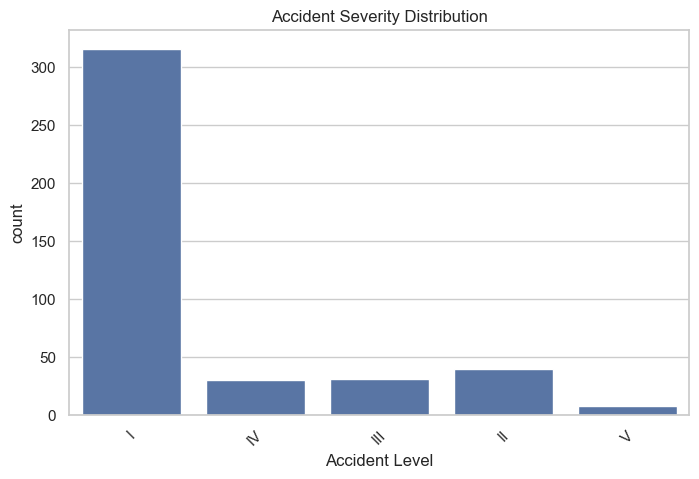

Accident Level
I      0.743529
II     0.094118
III    0.072941
IV     0.070588
V      0.018824
Name: proportion, dtype: float64


In [6]:
target_col = [c for c in df.columns if 'accident' in c.lower() and 'level' in c.lower()][0]

plt.figure(figsize=(8,5))
sns.countplot(x=target_col, data=df)
plt.title("Accident Severity Distribution")
plt.xticks(rotation=45)
plt.show()

print(df[target_col].value_counts(normalize=True))

Class Imbalanced are observed which required weighted model


#### 6. Categorical Feature Analysis

/var/folders/f7/nqdflyb92mj4gsk16y3l1lyh0000gn/T/ipykernel_85655/1857962519.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


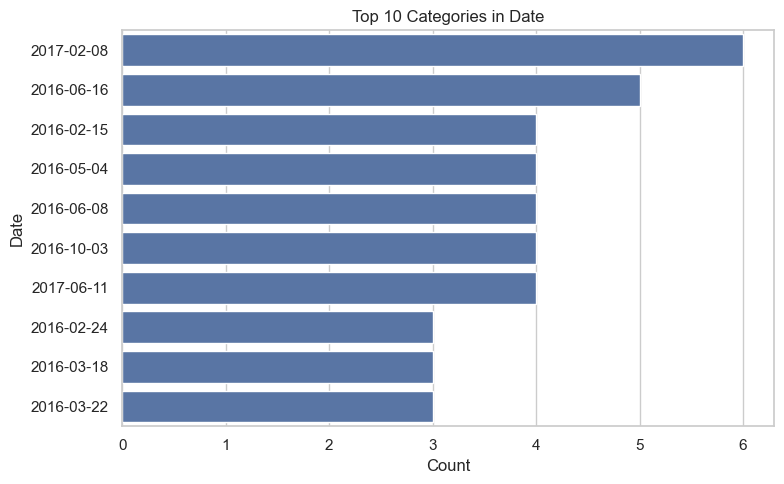

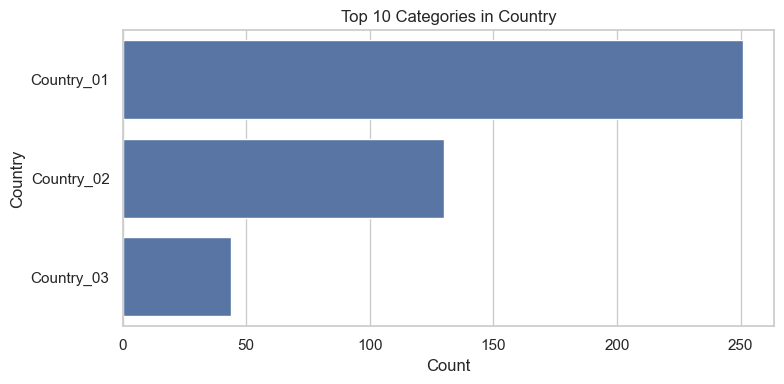

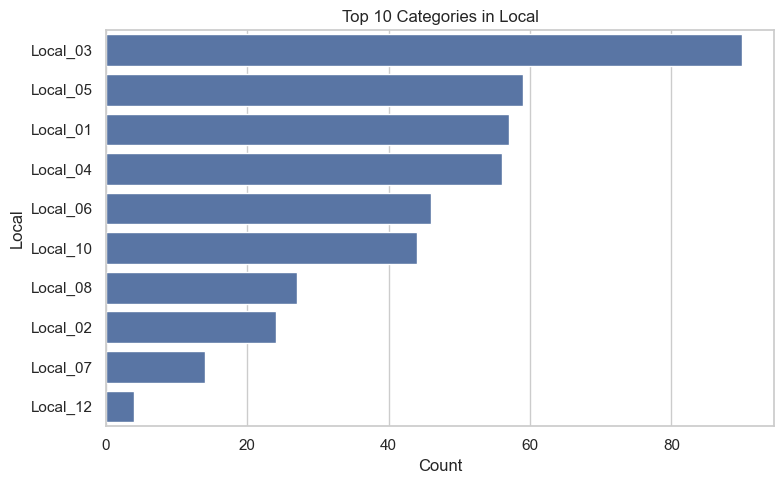

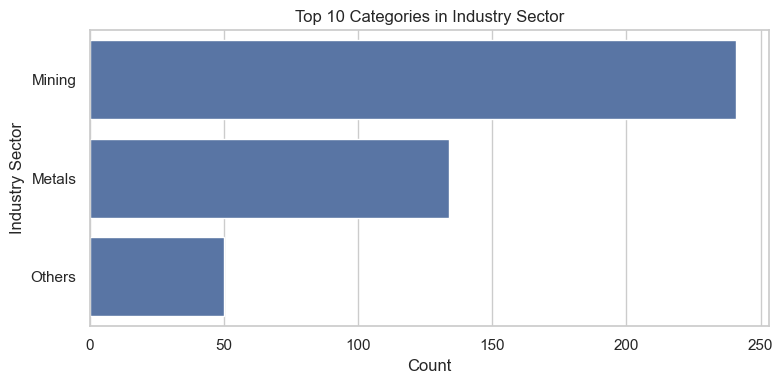

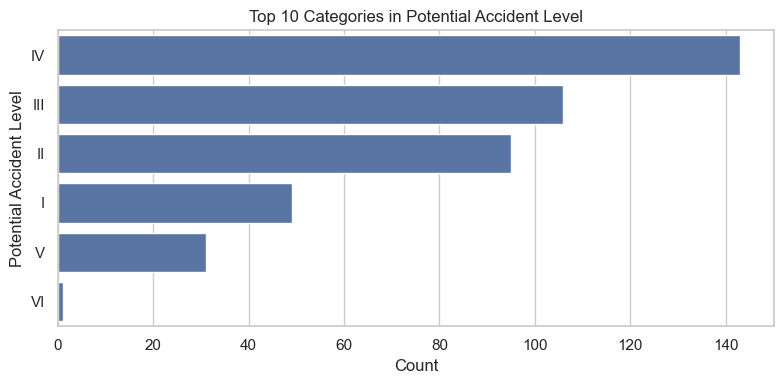

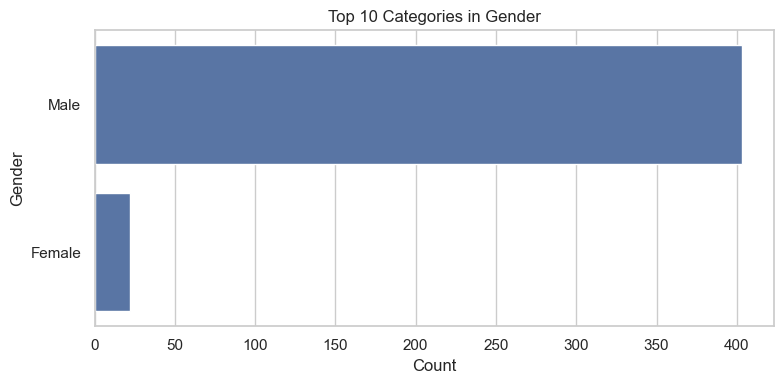

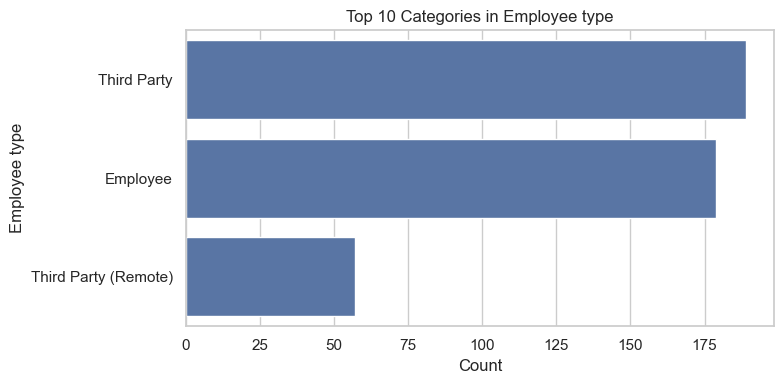

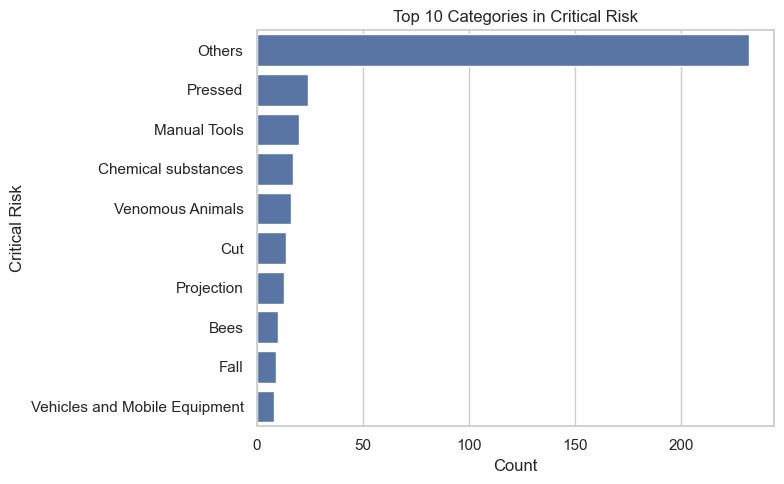

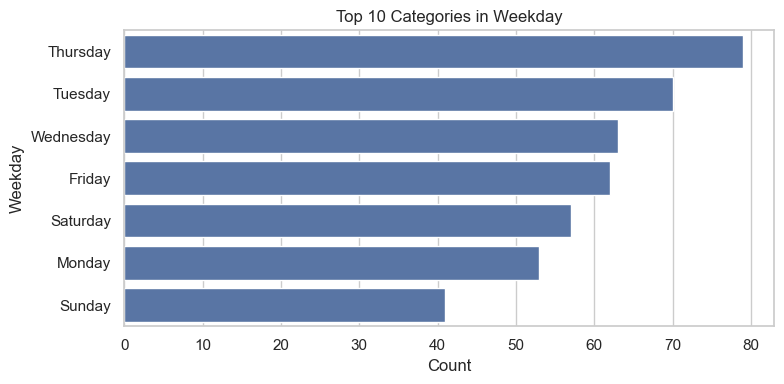

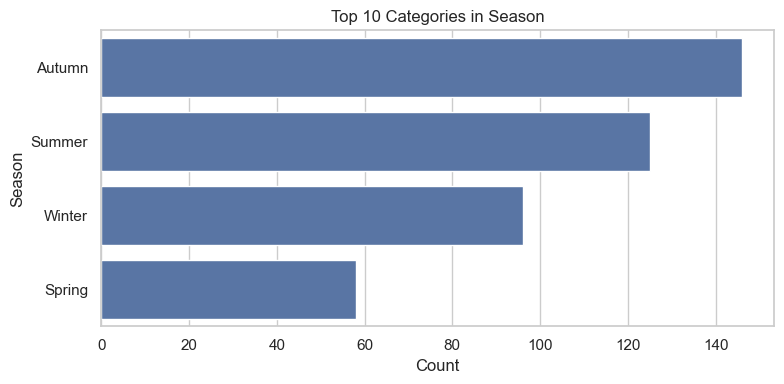

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

cat_cols = [c for c in cat_cols if c != target_col and 'desc' not in c.lower()]

def plot_categorical_clean(df, col, top_n=10):
    
    # Get top categories
    data = df[col].value_counts().nlargest(top_n)
    
    plt.figure(figsize=(8, max(4, len(data)*0.5)))
    
    sns.barplot(x=data.values, y=data.index)
    
    plt.title(f"Top {top_n} Categories in {col}", fontsize=12)
    plt.xlabel("Count")
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_categorical_clean(df, col)

#### Obeservations
1. Country 01 and Local 03 are the highest contributors in the industrial accident that has happened in past 6 months.
2. Most of the accident observed in the collected data are belong to mining industry. 
3. We can see most of the accidents are moderately severe and we can see there is only one accident that falls under severity of rating 6. Clearly indicates class imbalanced data. 
4. In terms of employee, employee who are at sites and belongs to third party have significantly high in numbers who were get injured in these accidents. In terms of Genders most of these employees are male. 
5. Thursday is the day of week when most of the accidents happened and Autumn season contributes highest in terms of number of accidents that has happened. Where in Spring is the season which has least amount of accidednts happened across industries. 

#### 7. Numerical Feature Distribution

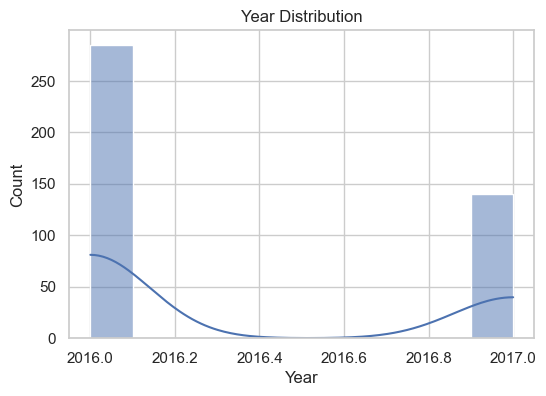

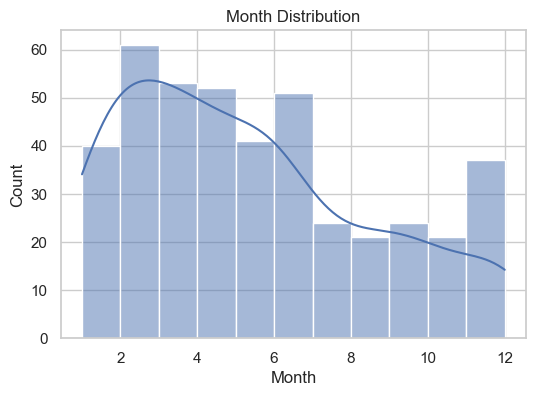

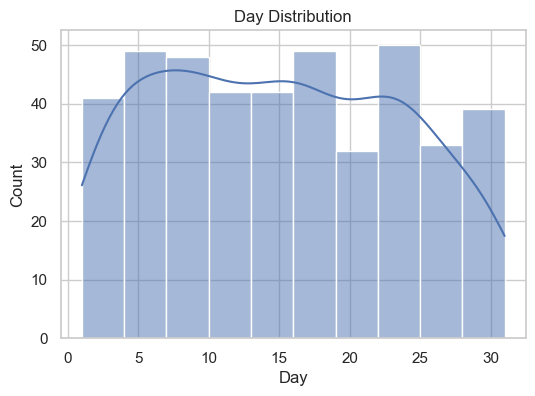

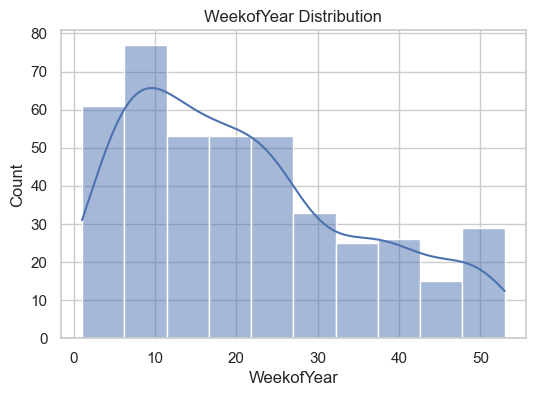

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

#### 8. Text Column Identification

In [12]:
text_col = [c for c in df.columns if 'desc' in c.lower()][0]

print("Text column:", text_col)

Text column: Description


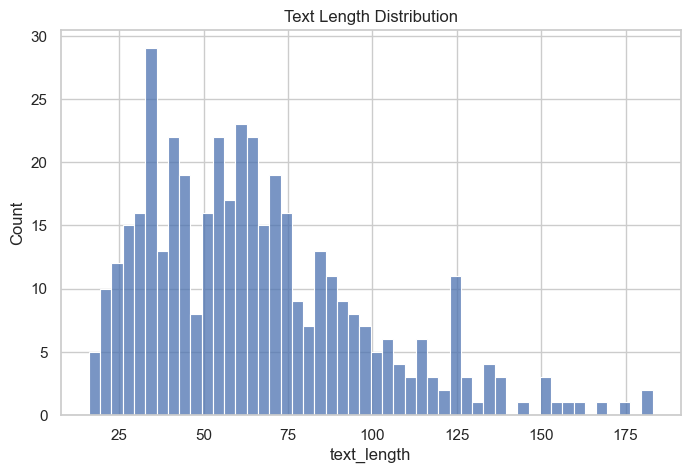

In [13]:
df['text_length'] = df[text_col].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

#### Word Frequency

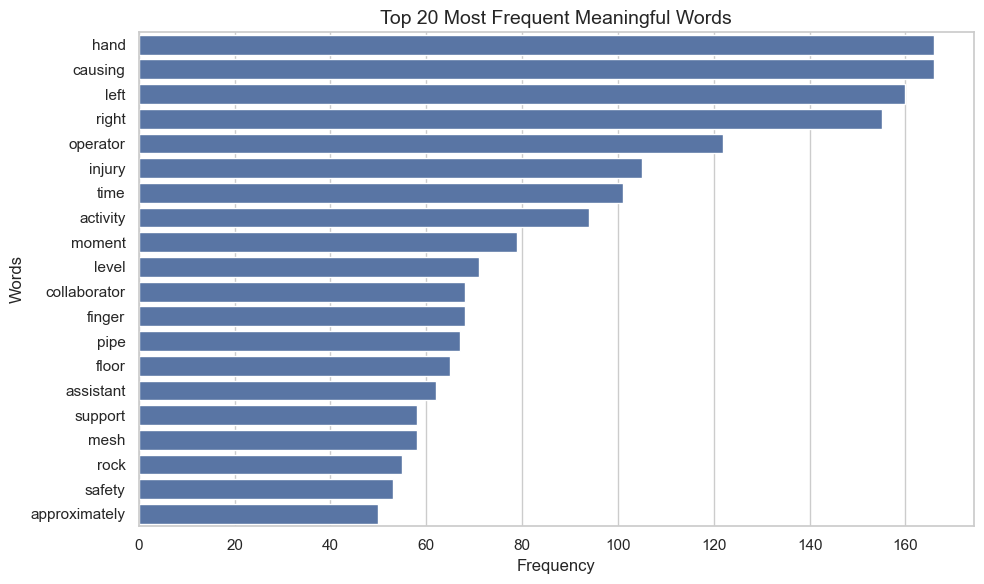

In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

custom_stopwords = {
    'employee', 'worker', 'incident', 'accident',
    'work', 'area', 'site', 'equipment'
}

stop_words = stop_words.union(custom_stopwords)

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return " ".join(words)

text_col = [c for c in df.columns if 'desc' in c.lower()][0]

cleaned_text = df[text_col].apply(clean_text)

all_words = " ".join(cleaned_text).split()

from collections import Counter

common_words = Counter(all_words).most_common(20)

words_df = pd.DataFrame(common_words, columns=['Word','Count'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=words_df,
    x='Count',
    y='Word'
)

plt.title("Top 20 Most Frequent Meaningful Words", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

#### Word Cloud

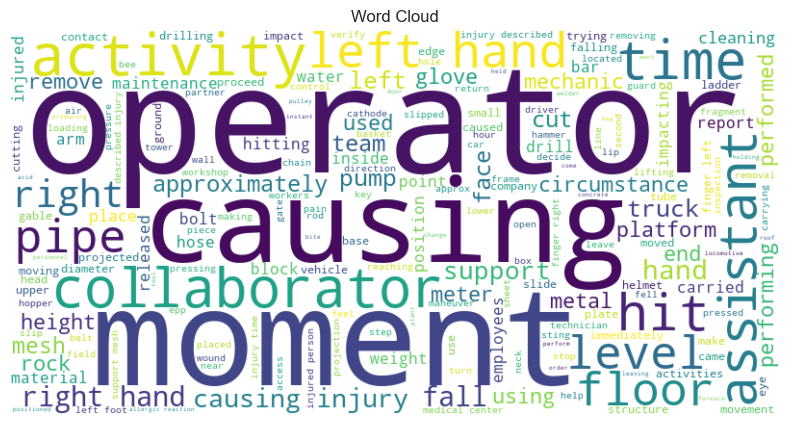

In [21]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()